In [3]:
import os
os.chdir('c:\\Users\\Mikael Huff\\Documents\\Training')
os.getcwd()

'c:\\Users\\Mikael Huff\\Documents\\Training'

# Time Series Analysis using ARIMA

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [7]:
df = pd.read_csv('data/Electric_Production.csv')
df.head()

,DATE,IPG2211A2N
0,1/1/1985,72.5052
1,2/1/1985,70.6720
2,3/1/1985,62.4502
3,4/1/1985,57.4714
4,5/1/1985,55.3151


In [12]:
df = df.rename(columns={'DATE':'ds', 'IPG2211A2N':'ts'})

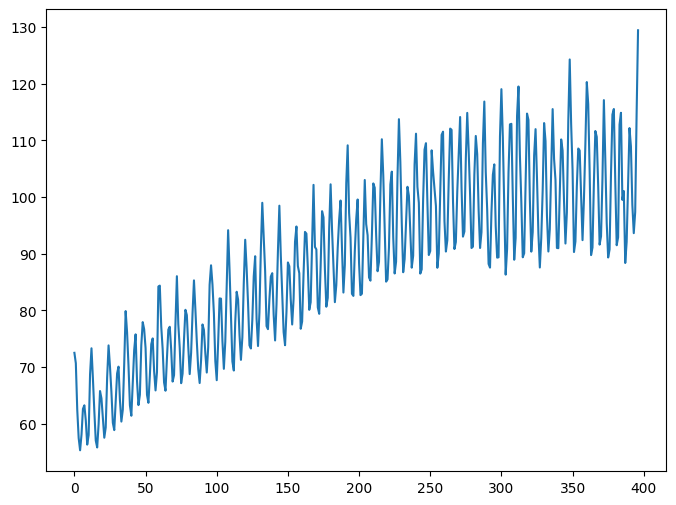

In [14]:
plt.figure(figsize=(8,6))
plt.plot(df.ts)

## Signal Decomposition (Trend, Seasonality, and Residual)

In [18]:
# Log Tranform
def log_transform(df,ts): 
    return df[ts].apply(lambda x:np.log(x))

In [20]:
df['ts_log'] = log_transform(df, ts='ts')
df.head()

,ds,ts,ts_log
0,1/1/1985,72.5052,4.283658
1,2/1/1985,70.6720,4.258049
2,3/1/1985,62.4502,4.134369
3,4/1/1985,57.4714,4.051287
4,5/1/1985,55.3151,4.013046


In [23]:
from statsmodels.tsa.seasonal import seasonal_decompose

In [36]:
decomposition = seasonal_decompose(df['ts'], period=48, extrapolate_trend=3)

In [37]:
def plot_decomposition(df, ts='ts', trend='trend', seasonal='seasonal', residual='residuals'):
  f, ((ax1,ax2),(ax3,ax4)) = plt.subplots(2,2, figsize=(15,8), sharex=True )

  ax1.plot(df[ts], label="Original")
  ax1.legend(loc='best')
  ax1.tick_params(axis ='x', rotation=45)

  ax2.plot(df[trend], label="Trend")
  ax2.legend(loc='best')
  ax2.tick_params(axis ='x', rotation=45)

  ax3.plot(df[seasonal], label="Seasonal")
  ax3.legend(loc='best')
  ax3.tick_params(axis ='x', rotation=45)

  ax4.plot(df[residual], label="Residuals")
  ax4.legend(loc='best')
  ax4.tick_params(axis ='x', rotation=45)

  plt.tight_layout()
  plt.show()

In [38]:
new_df = df.copy()
new_df.loc[:,'trend'] = decomposition.trend
new_df.loc[:,'seasonal'] = decomposition.seasonal
new_df.loc[:,'residuals'] = decomposition.resid
new_df.head()

,ds,ts,ts_log,trend,seasonal,residuals
0,1/1/1985,72.5052,4.283658,61.180474,12.806228,-1.481503
1,2/1/1985,70.6720,4.258049,61.344576,4.567898,4.759527
2,3/1/1985,62.4502,4.134369,61.508677,0.080078,0.861445
3,4/1/1985,57.4714,4.051287,61.672778,-9.488523,5.287145
4,5/1/1985,55.3151,4.013046,61.836879,-10.231015,3.709237


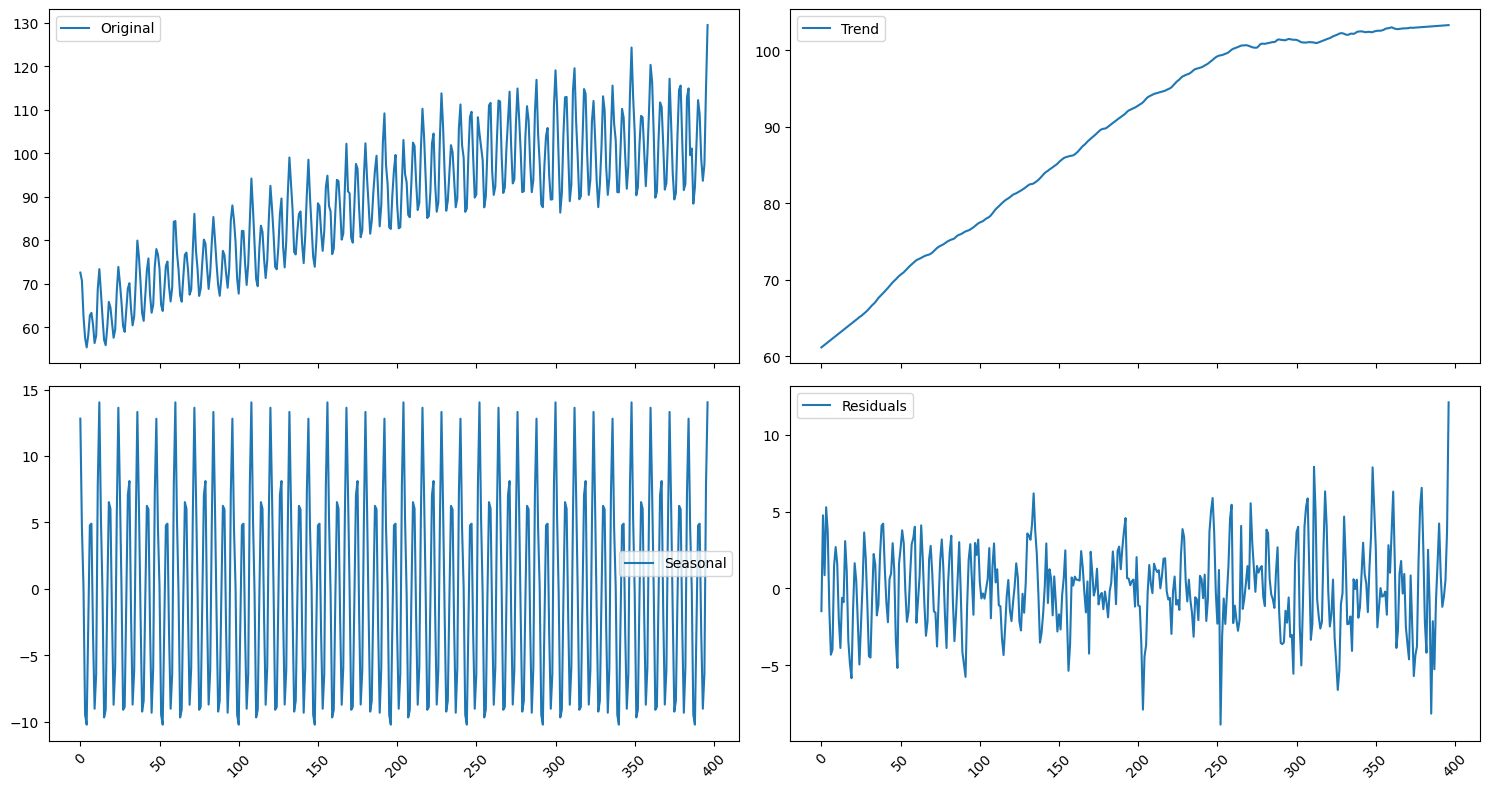

In [39]:
plot_decomposition(new_df)

### Stationarity Test: Dickey Fuller Test

In [40]:
from statsmodels.tsa.stattools import adfuller

In [42]:
dftest = adfuller(new_df['residuals'], autolag='AIC')

In [ ]:
def test_stationarity(df, ts):

  rolmean = df[ts].rolling(window=12, center= False).mean()
  rolstd =  df[ts].rolling(window=12, center = False).std()

  orig = plt.plot(df[ts], color = 'blue', label ="Original")
  mean = plt.plot(rolmean, color ='red', label ="Rolling Mean")
  std = plt.plot(rolstd, color='black', label ="Rolling Std")
  plt.legend(loc = 'best')
  plt.title("Rolling Mean and Standard Deviation for  %s" %(ts))
  plt.xticks(rotation =45)
  plt.show(block = False)
  plt.close

  print('Results:')
  dftest = adfuller(df[ts], autolag='AIC')
  dfoutput = pd.Series(dftest[0:4], index=["Test Statistic",'p=value','# Lasgs Used',' Number of Observations'])  

  for key, value in dftest[4].items():
    dfoutput['Critical Value(%s)' %key]= value

  print(dfoutput)

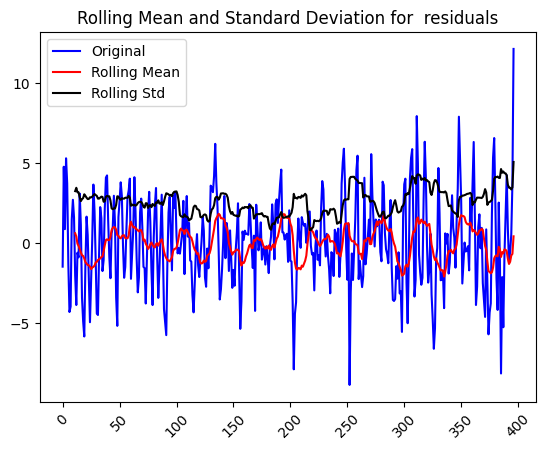

Results:
Test Statistic            -6.019455e+00
p=value                    1.505908e-07
# Lasgs Used               1.500000e+01
 Number of Observations    3.810000e+02
Critical Value(1%)        -3.447631e+00
Critical Value(5%)        -2.869156e+00
Critical Value(10%)       -2.570827e+00
dtype: float64


In [46]:
test_stationarity(new_df, ts='residuals')

### Autocorrelation and Partial Autocorrelation Plots

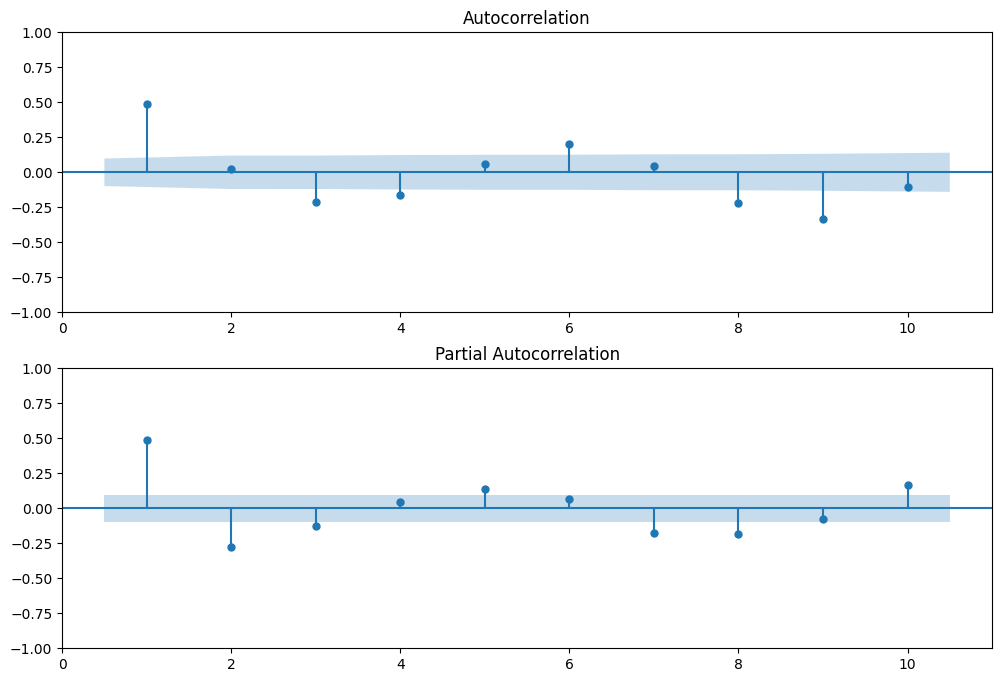

In [49]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Create figure
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12,8))

# Plot the ACF of df
plot_acf(new_df['residuals'], lags=10, zero=False, ax=ax1);

# Plot the PACF of df
plot_pacf(new_df['residuals'], lags=10, zero=False, ax=ax2);

## Forecasting using ARIMA

In [51]:
from statsmodels.tsa.arima.model import ARIMA

In [52]:
def run_Arima(df,ts,p,d,q):
  model =ARIMA(df[ts], order=(p,d,q))
  results_arima=model.fit()

  len_results =len(results_arima.fittedvalues)
  ts_modified =df[ts][-len_results:]

  rss = sum((results_arima.fittedvalues-ts_modified)**2)
  rmse = np.sqrt(rss/len(df[ts]))
  print("RMSE: ",rmse)

  plt.figure()
  plt.plot(df[ts])
  plt.plot(results_arima.fittedvalues, color='red')
  plt.show()

  return results_arima

RMSE:  2.052020223142051


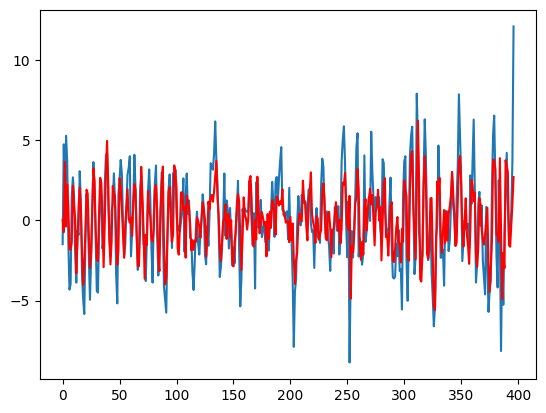

In [54]:
new_df = new_df.fillna(value=0)
model_AR = run_Arima(new_df, ts='residuals', p=15, d=0, q=0)

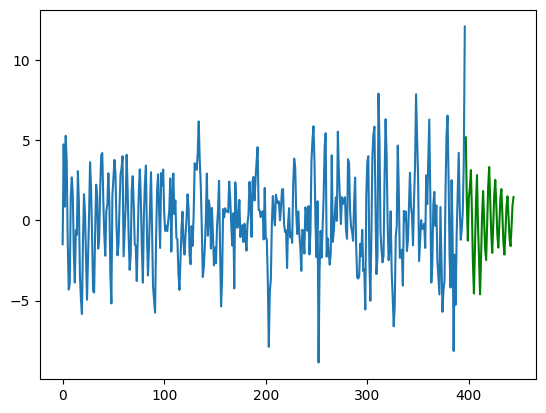

In [57]:
my_forecast = model_AR.forecast(48)

plt.figure()
plt.plot(new_df['residuals'])
plt.plot(my_forecast, color='green')

In [59]:
model_AR.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:              residuals   No. Observations:                  397
Model:                ARIMA(15, 0, 0)   Log Likelihood                -847.229
Date:                Thu, 09 Oct 2025   AIC                           1728.458
Time:                        09:32:10   BIC                           1796.185
Sample:                             0   HQIC                          1755.287
                                - 397                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0340      0.121      0.282      0.778      -0.202       0.270
ar.L1          0.5416      0.047     11.618      0.000       0.450       0.633
ar.L2         -0.1101      0.054     -2.027      0.043      -0.217      -0.004
ar.L3          0.0037      0.064      0.058      0.954      -0.122       0.130
ar.L4         -0.0704      0.065     -1.081      0.280      -0.198       0.057
ar.L5          0.0081      0.066      0.123      0.902      -0.121       0.137
ar.L6          0.0812      0.058      1.410      0.158      -0.032       0.194
ar.L7         -0.0455      0.064     -0.709      0.478      -0.171       0.080
ar.L8         -0.1032      0.061     -1.702      0.089      -0.222       0.016
ar.L9         -0.1652      0.065     -2.540      0.011      -0.293      -0.038
ar.L10         0.1172      0.055      2.116      0.034       0.009       0.226
ar.L11         0.0055      0.056      0.097      0.922      -0.105       0.116
ar.L12         0.1681      0.067      2.527      0.012       0.038       0.298
ar.L13        -0.1833      0.053     -3.469      0.001      -0.287      -0.080
ar.L14         0.0283      0.062      0.460      0.646      -0.092       0.149
ar.L15        -0.2075      0.062     -3.341      0.001      -0.329      -0.086
sigma2         4.1458      0.227     18.231      0.000       3.700       4.591
===================================================================================
Ljung-Box (L1) (Q):                   0.13   Jarque-Bera (JB):               117.08
Prob(Q):                              0.72   Prob(JB):                         0.00
Heteroskedasticity (H):               1.98   Skew:                            -0.18
Prob(H) (two-sided):                  0.00   Kurtosis:                         5.64
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [62]:
model_AR.conf_int(alpha=.05)

,0,1
const,-0.202228,0.270160
ar.L1,0.450241,0.632972
ar.L2,-0.216513,-0.003666
ar.L3,-0.122247,0.129715
ar.L4,-0.197943,0.057199
ar.L5,-0.121183,0.137365
ar.L6,-0.031622,0.193944
ar.L7,-0.171356,0.080333
ar.L8,-0.221976,0.015632
ar.L9,-0.292658,-0.037733


In [63]:
from statsmodels.graphics.tsaplots import plot_predict

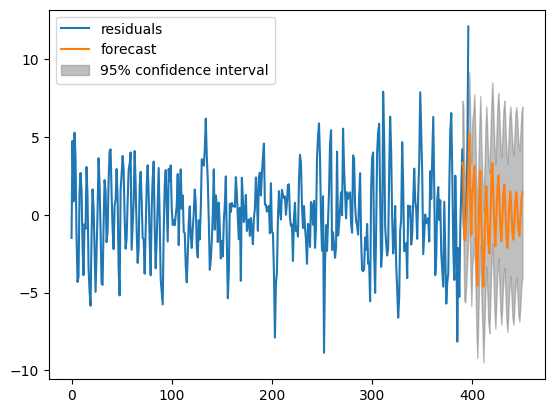

In [65]:
fig, ax = plt.subplots()
ax = new_df['residuals'].plot(ax=ax)
plot_predict(model_AR,390,450, ax=ax)
plt.show()